In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('nassau_candy_clean.csv')
route_stats   = pd.read_csv('route_stats.csv')
region_stats  = pd.read_csv('region_stats.csv')
shipmode_stats = pd.read_csv('shipmode_stats.csv')

sns.set_theme(style='whitegrid')
print("All files loaded. Rows in df:", len(df))

All files loaded. Rows in df: 10194


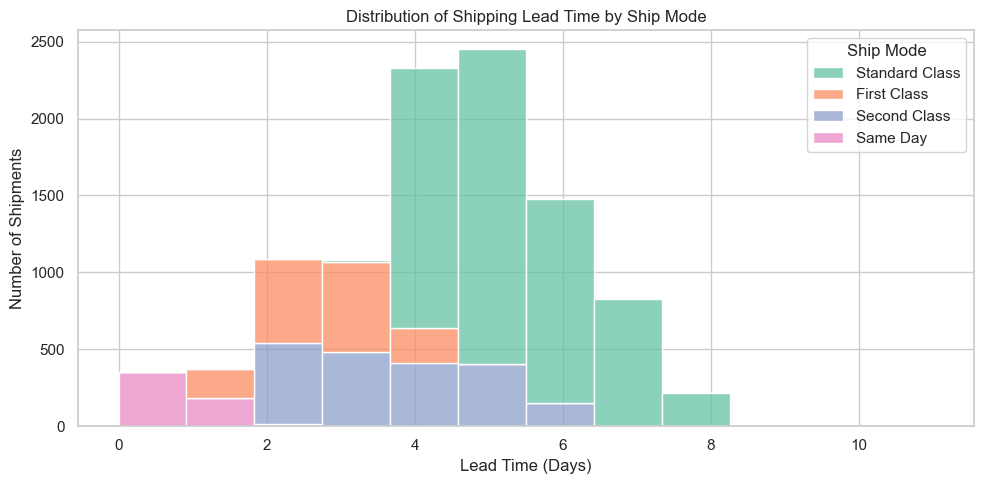

✅ Saved chart1


In [2]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x='Lead Time (Days)', bins=12,
             hue='Ship Mode', multiple='stack', palette='Set2')

plt.title('Distribution of Shipping Lead Time by Ship Mode')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Shipments')
plt.tight_layout()
plt.savefig('chart1_lead_time_distribution.png', dpi=150)
plt.show()
print("✅ Saved chart1")

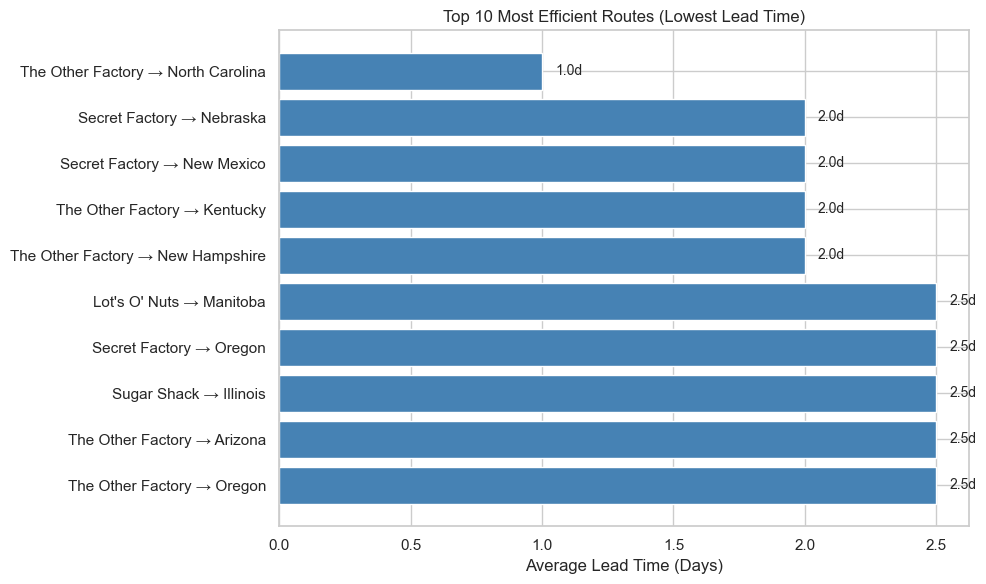

✅ Saved chart2


In [3]:
top10 = route_stats.nlargest(10, 'Efficiency_Score')

plt.figure(figsize=(10, 6))
bars = plt.barh(top10['Route'], top10['Avg_Lead_Time'],
                color='steelblue', edgecolor='white')

plt.xlabel('Average Lead Time (Days)')
plt.title('Top 10 Most Efficient Routes (Lowest Lead Time)')
plt.gca().invert_yaxis()

for bar, val in zip(bars, top10['Avg_Lead_Time']):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}d', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart2_top10_routes.png', dpi=150)
plt.show()
print("✅ Saved chart2")

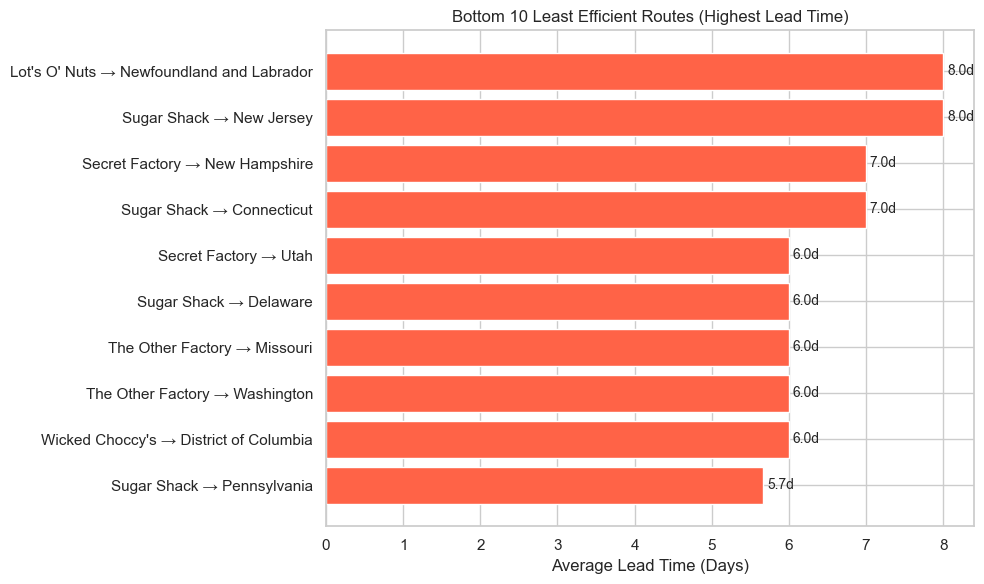

✅ Saved chart3


In [4]:
bottom10 = route_stats.nsmallest(10, 'Efficiency_Score')

plt.figure(figsize=(10, 6))
bars = plt.barh(bottom10['Route'], bottom10['Avg_Lead_Time'],
                color='tomato', edgecolor='white')

plt.xlabel('Average Lead Time (Days)')
plt.title('Bottom 10 Least Efficient Routes (Highest Lead Time)')
plt.gca().invert_yaxis()

for bar, val in zip(bars, bottom10['Avg_Lead_Time']):
    plt.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}d', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart3_bottom10_routes.png', dpi=150)
plt.show()
print("✅ Saved chart3")

C:\Users\rahvj\AppData\Local\Temp\ipykernel_8584\3681167430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ship Mode', y='Lead Time (Days)',


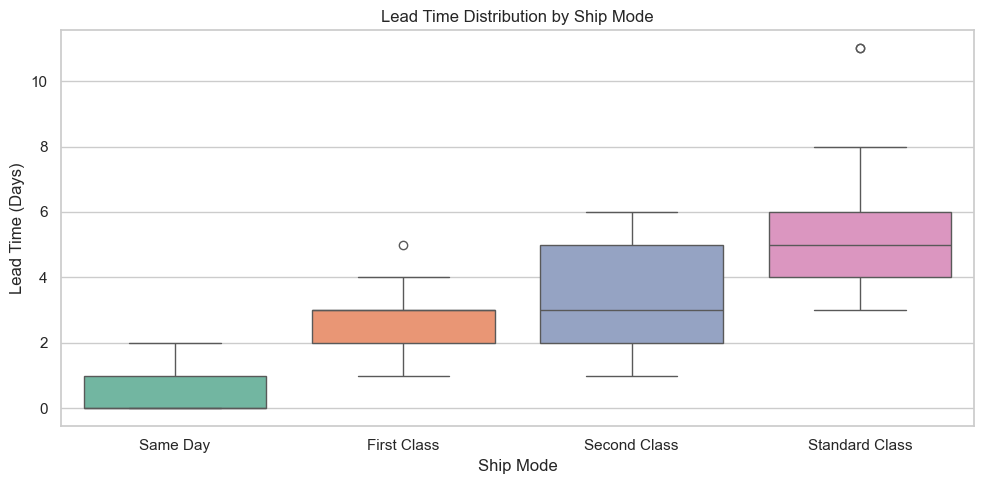

✅ Saved chart4


In [5]:
plt.figure(figsize=(10, 5))

order = ['Same Day', 'First Class', 'Second Class', 'Standard Class']
sns.boxplot(data=df, x='Ship Mode', y='Lead Time (Days)',
            order=order, palette='Set2')

plt.title('Lead Time Distribution by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Lead Time (Days)')
plt.tight_layout()
plt.savefig('chart4_shipmode_boxplot.png', dpi=150)
plt.show()
print("✅ Saved chart4")

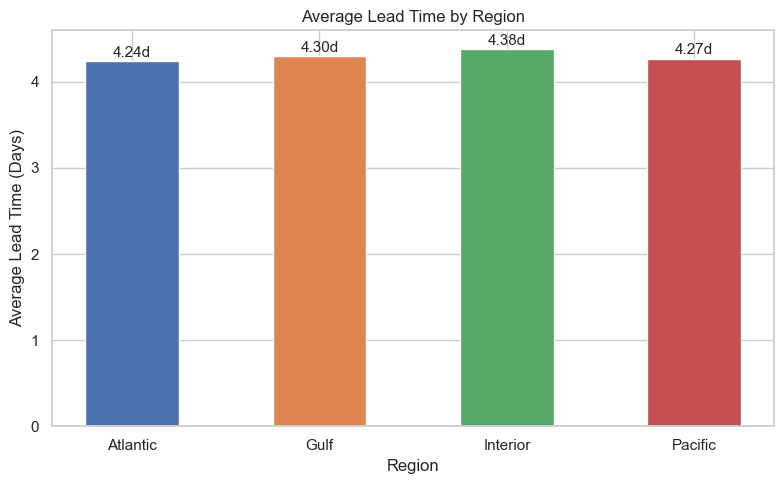

✅ Saved chart5


In [6]:
plt.figure(figsize=(8, 5))

bars = plt.bar(region_stats['Region'], region_stats['Avg_Lead_Time'],
               color=['#4C72B0','#DD8452','#55A868','#C44E52'],
               edgecolor='white', width=0.5)

plt.title('Average Lead Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Lead Time (Days)')

for bar, val in zip(bars, region_stats['Avg_Lead_Time']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.05,
             f'{val:.2f}d', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('chart5_region_leadtime.png', dpi=150)
plt.show()
print("✅ Saved chart5")

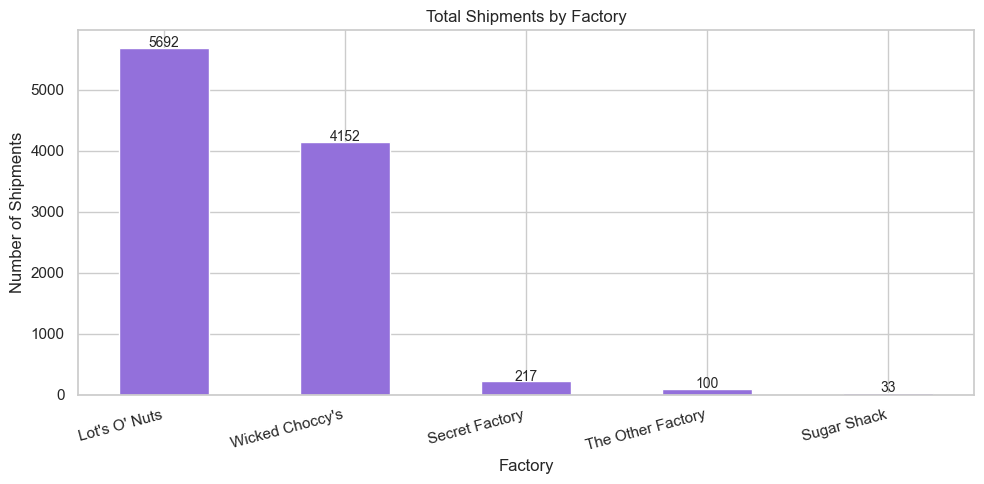

✅ Saved chart6


In [7]:
factory_vol = df['Factory'].value_counts().reset_index()
factory_vol.columns = ['Factory', 'Shipments']

plt.figure(figsize=(10, 5))
bars = plt.bar(factory_vol['Factory'], factory_vol['Shipments'],
               color='mediumpurple', edgecolor='white', width=0.5)

plt.title('Total Shipments by Factory')
plt.xlabel('Factory')
plt.ylabel('Number of Shipments')
plt.xticks(rotation=15, ha='right')

for bar, val in zip(bars, factory_vol['Shipments']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 10,
             str(val), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('chart6_factory_volume.png', dpi=150)
plt.show()
print("✅ Saved chart6")

In [8]:
import os
charts = [f for f in os.listdir('.') if f.startswith('chart') and f.endswith('.png')]
print(f"Total charts saved: {len(charts)}")
for c in sorted(charts):
    print(" ✅", c)

Total charts saved: 6
 ✅ chart1_lead_time_distribution.png
 ✅ chart2_top10_routes.png
 ✅ chart3_bottom10_routes.png
 ✅ chart4_shipmode_boxplot.png
 ✅ chart5_region_leadtime.png
 ✅ chart6_factory_volume.png
